In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("default")

In [8]:
DATA_FILE = Path(
    "../SMEFT_bbyy_h5files/new_Input_bbyy_SMEFT_cbgim_linOnly_7thJune_2026.h5"
)

In [9]:
with h5py.File(DATA_FILE, "r") as f:

    def print_structure(name, obj):
        print(name)

    f.visititems(print_structure)

ForAnalysis
ForAnalysis/1d
ForAnalysis/2d


In [10]:
with h5py.File(DATA_FILE, "r") as f:

    data = f["ForAnalysis/1d"][:]

df = pd.DataFrame(data)

print(df.shape)

df.head()

(49727, 39)


,DPhi_bb,DPhi_yybb,Eta_jj,Eta_yybb,EventNumber,Higgs_Eta,Higgs_Mass,Higgs_Phi,Higgs_pT,LeadJet_Eta,...,costheta1,costheta2,is_HHEvent,is_SingleHiggsEvent,is_SingleZEvent,is_ZHEvent,m_bbyy,nBTaggedJets,pT_jj,signed_DeltaPhi_jj
0,1.989259,-1.892753,-1.927046,-2.570114,0,0.964493,125.612114,-1.656880,63.199715,-1.323911,...,-0.247231,-0.206321,False,True,False,False,410.591003,2,86.266327,0.763582
1,2.250293,-1.515379,3.735356,3.112419,0,0.522622,124.562790,-3.047172,87.697372,2.597662,...,-0.191825,0.036395,False,True,False,False,451.395020,2,37.667587,3.573506
2,2.922382,-1.603222,3.452072,3.875891,0,2.507100,117.335014,1.135511,59.098190,3.587198,...,-0.347918,0.247666,False,False,False,False,247.935913,2,57.236889,5.985050
3,2.021205,-1.015635,1.688882,2.262023,0,1.244022,126.120171,2.979867,126.800911,1.165992,...,-0.461304,-0.194784,False,True,False,False,249.386414,2,64.275253,0.049966
4,0.388992,-0.825524,1.359896,1.497616,0,-0.240742,125.885040,-0.939146,155.546066,1.009811,...,0.494670,0.179895,False,True,False,False,377.486633,2,93.385857,0.746417


In [11]:
print(df.columns.tolist())

['DPhi_bb', 'DPhi_yybb', 'Eta_jj', 'Eta_yybb', 'EventNumber', 'Higgs_Eta', 'Higgs_Mass', 'Higgs_Phi', 'Higgs_pT', 'LeadJet_Eta', 'LeadJet_M', 'LeadJet_Phi', 'LeadJet_pT', 'LeadPhoton_Eta', 'LeadPhoton_Phi', 'LeadPhoton_pT', 'Lumi_weight', 'M_jj', 'NJets', 'Phi1', 'Phi_jj', 'SubLeadJet_Eta', 'SubLeadJet_M', 'SubLeadJet_Phi', 'SubLeadJet_pT', 'SubLeadPhoton_Eta', 'SubLeadPhoton_Phi', 'SubLeadPhoton_pT', 'cosThetaStar', 'costheta1', 'costheta2', 'is_HHEvent', 'is_SingleHiggsEvent', 'is_SingleZEvent', 'is_ZHEvent', 'm_bbyy', 'nBTaggedJets', 'pT_jj', 'signed_DeltaPhi_jj']


In [12]:
df["Lumi_weight"].describe()

count    49727.000000
mean         0.000466
std          0.055706
min         -0.056217
25%         -0.055696
50%          0.055324
75%          0.055698
max          0.056217
Name: Lumi_weight, dtype: float64

In [13]:
positive_df = df[df["Lumi_weight"] > 0]

negative_df = df[df["Lumi_weight"] < 0]

print(f"Total Events     : {len(df):,}")
print(f"Positive Events  : {len(positive_df):,}")
print(f"Negative Events  : {len(negative_df):,}")

Total Events     : 49,727
Positive Events  : 25,071
Negative Events  : 24,656


In [14]:
positive_fraction = len(positive_df) / len(df)

negative_fraction = len(negative_df) / len(df)

print(f"Positive Fraction = {positive_fraction:.3f}")

print(f"Negative Fraction = {negative_fraction:.3f}")

Positive Fraction = 0.504
Negative Fraction = 0.496


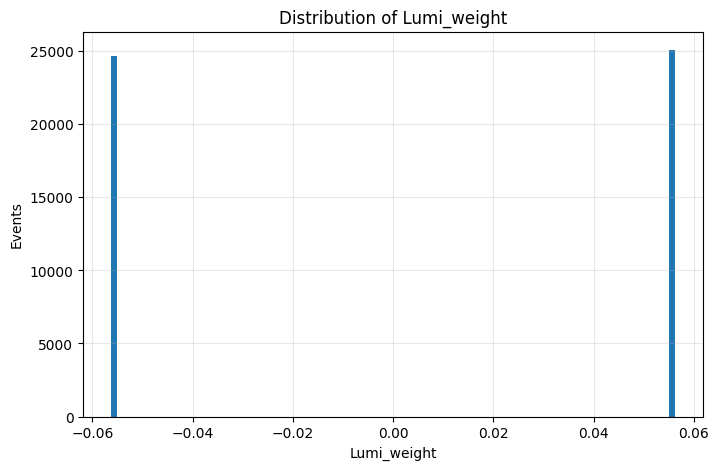

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Lumi_weight"],
    bins=100
)

plt.xlabel("Lumi_weight")

plt.ylabel("Events")

plt.title("Distribution of Lumi_weight")

plt.grid(alpha=0.3)

plt.show()

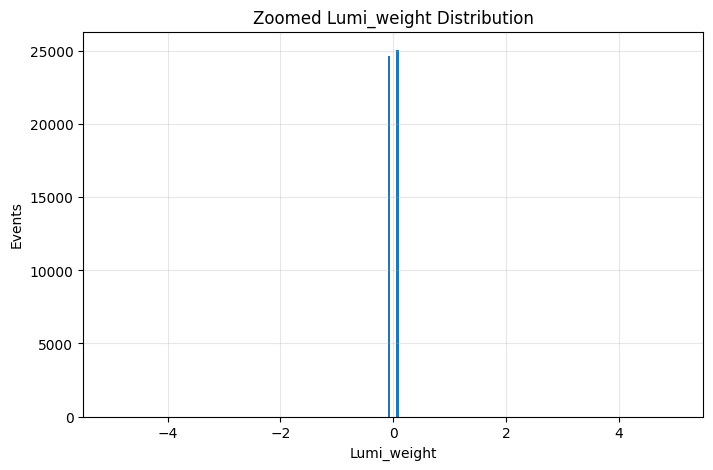

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Lumi_weight"],
    bins=200,
    range=(-5,5)
)

plt.xlabel("Lumi_weight")

plt.ylabel("Events")

plt.title("Zoomed Lumi_weight Distribution")

plt.grid(alpha=0.3)

plt.show()

In [18]:
plot_configs = {

    "Higgs_pT": {
        "range": (0,500)
    },

    "m_bbyy": {
        "range": (200,1000)
    },

    "M_jj": {
        "range": (0,250)
    },

    "DPhi_bb": {
        "range": (0,np.pi)
    },

    "signed_DeltaPhi_jj": {
        "range": (-np.pi,np.pi)
    },

    "costheta1": {
        "range": (-1,1)
    }
}

In [19]:
def compare_positive_negative(
    observable,
    bins=50
):

    plt.figure(figsize=(8,5))

    plt.hist(
        positive_df[observable],
        bins=bins,
        range=plot_configs[observable]["range"],
        density=True,
        histtype="step",
        linewidth=2,
        label="Lumi_weight > 0"
    )

    plt.hist(
        negative_df[observable],
        bins=bins,
        range=plot_configs[observable]["range"],
        density=True,
        histtype="step",
        linewidth=2,
        label="Lumi_weight < 0"
    )

    plt.xlabel(observable)

    plt.ylabel("Normalized Events")

    plt.title(observable)

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

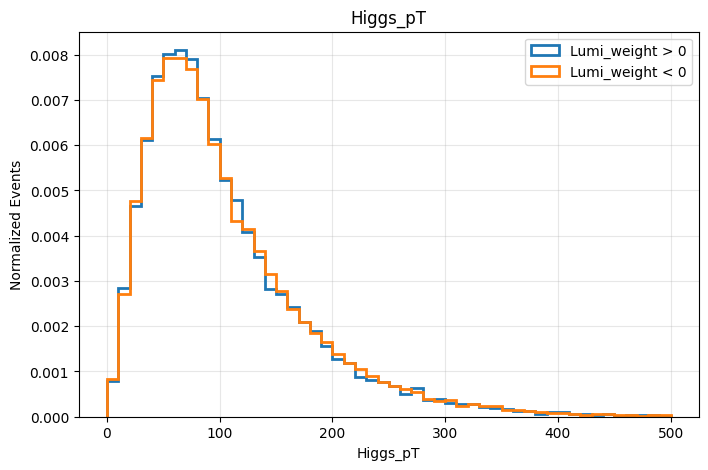

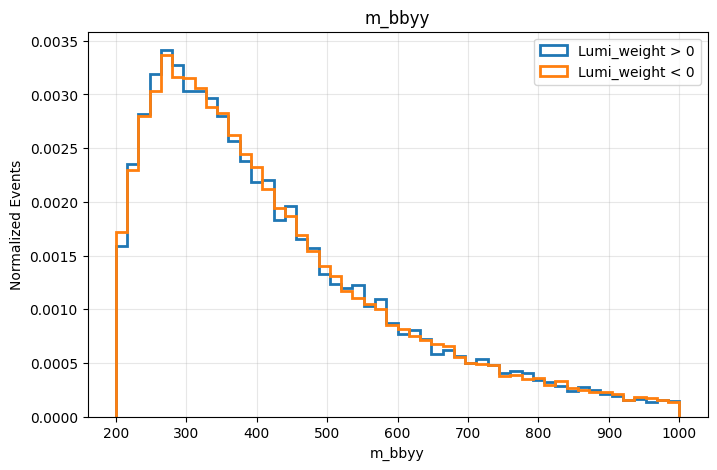

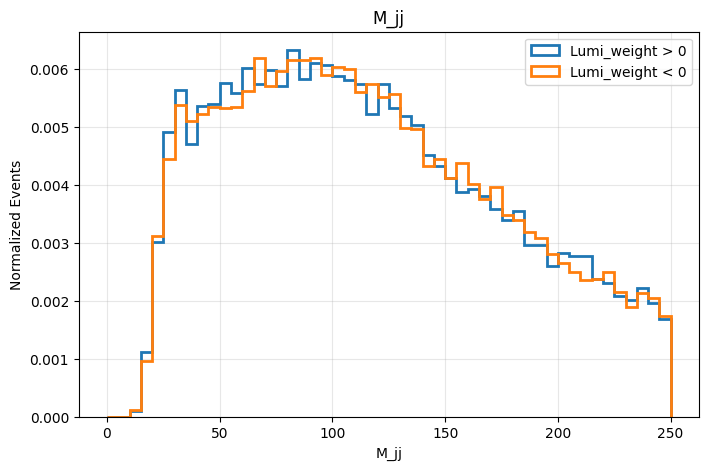

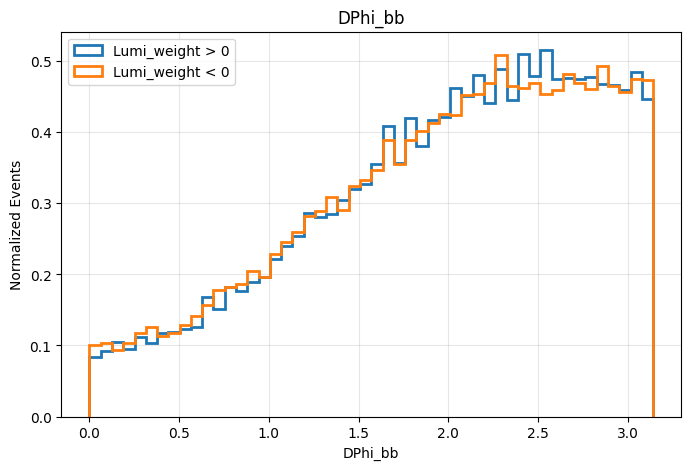

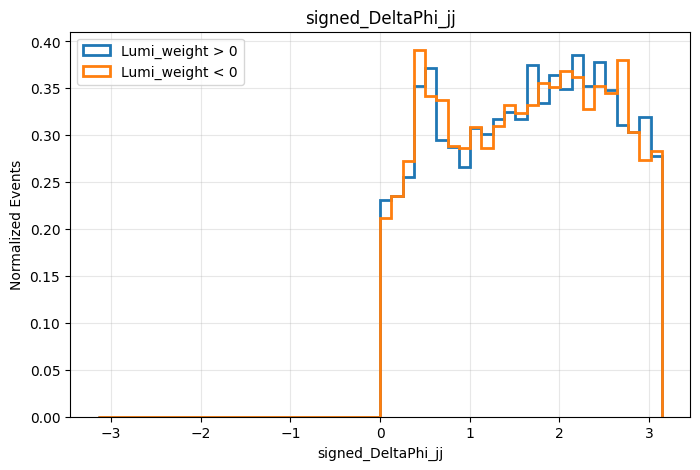

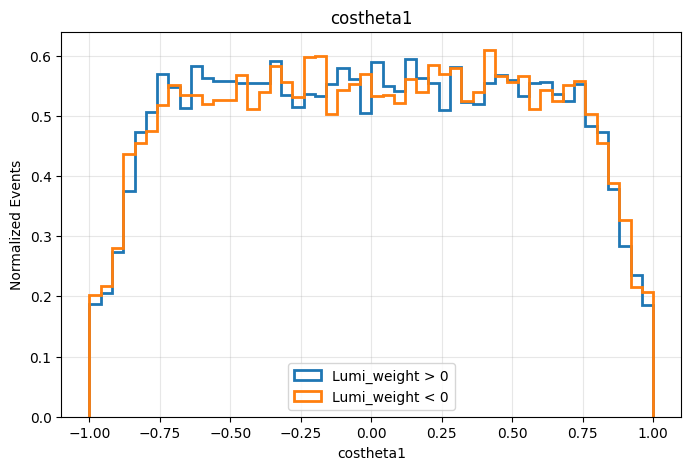

In [21]:
observables = [

    "Higgs_pT",

    "m_bbyy",

    "M_jj",

    "DPhi_bb",

    "signed_DeltaPhi_jj",

    "costheta1"
]

for obs in observables:

    compare_positive_negative(obs)

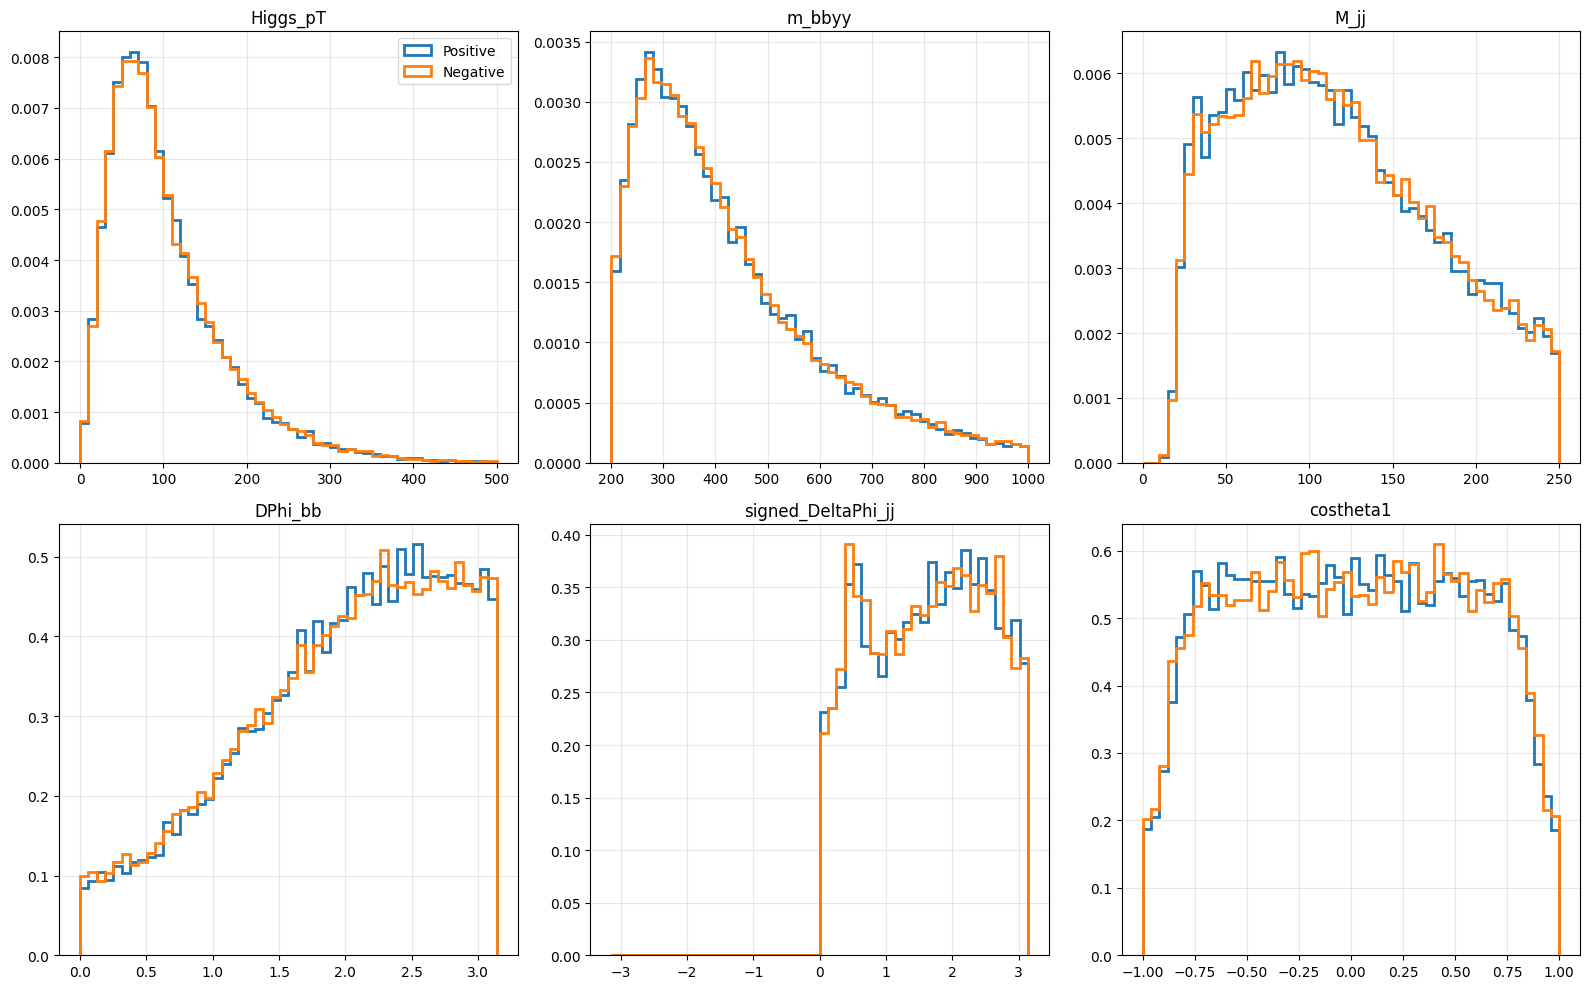

In [22]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(16,10)
)

axes = axes.flatten()

for i, obs in enumerate(observables):

    ax = axes[i]

    ax.hist(
        positive_df[obs],
        bins=50,
        range=plot_configs[obs]["range"],
        density=True,
        histtype="step",
        linewidth=2,
        label="Positive"
    )

    ax.hist(
        negative_df[obs],
        bins=50,
        range=plot_configs[obs]["range"],
        density=True,
        histtype="step",
        linewidth=2,
        label="Negative"
    )

    ax.set_title(obs)

    ax.grid(alpha=0.3)

    if i == 0:
        ax.legend()

plt.tight_layout()

plt.show()

In [23]:
results = []

for obs in observables:

    results.append({

        "Observable": obs,

        "Positive Mean":
            positive_df[obs].mean(),

        "Negative Mean":
            negative_df[obs].mean()
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Observable,Positive Mean,Negative Mean
0,Higgs_pT,105.083138,106.279991
1,m_bbyy,444.591919,445.117859
2,M_jj,167.390594,166.919540
3,DPhi_bb,1.971499,1.958548
4,signed_DeltaPhi_jj,3.138720,3.136819
5,costheta1,-0.001312,0.004373


In [24]:
comparison_df["Difference"] = np.abs(

    comparison_df["Positive Mean"]

    -

    comparison_df["Negative Mean"]
)

comparison_df.sort_values(
    "Difference",
    ascending=False
)

,Observable,Positive Mean,Negative Mean,Difference
0,Higgs_pT,105.083138,106.279991,1.196854
1,m_bbyy,444.591919,445.117859,0.525940
2,M_jj,167.390594,166.919540,0.471054
3,DPhi_bb,1.971499,1.958548,0.012951
5,costheta1,-0.001312,0.004373,0.005686
4,signed_DeltaPhi_jj,3.138720,3.136819,0.001901
